# Step 1: Exploratory Data Analysis (EDA)

Tujuan: Memahami struktur data, distribusi label, dan karakteristik teks sebelum preprocessing.

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Load Dataset

In [14]:
df = pd.read_csv('../data/raw/Tweets.csv')

print(f'Jumlah data: {len(df)}')
print(f'Jumlah kolom: {len(df.columns)}')
print(f'\nKolom: {df.columns.tolist()}')
print(f'\n5 baris pertama:')
df.head()

Jumlah data: 14640
Jumlah kolom: 15

Kolom: ['tweet_id', 'airline_sentiment', 'airline_sentiment_confidence', 'negativereason', 'negativereason_confidence', 'airline', 'airline_sentiment_gold', 'name', 'negativereason_gold', 'retweet_count', 'text', 'tweet_coord', 'tweet_created', 'tweet_location', 'user_timezone']

5 baris pertama:


,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


## 2. Info Dataset

In [15]:
print('=== Info Dataset ===')
df.info()

print(f'\n=== Missing Values ===')
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
if len(missing) > 0:
    print(missing)
    print(f'\nPersentase missing:')
    print((missing / len(df) * 100).round(2))
else:
    print('Tidak ada missing values')

=== Info Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14640 entries, 0 to 14639
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   tweet_id                      14640 non-null  int64  
 1   airline_sentiment             14640 non-null  object 
 2   airline_sentiment_confidence  14640 non-null  float64
 3   negativereason                9178 non-null   object 
 4   negativereason_confidence     10522 non-null  float64
 5   airline                       14640 non-null  object 
 6   airline_sentiment_gold        40 non-null     object 
 7   name                          14640 non-null  object 
 8   negativereason_gold           32 non-null     object 
 9   retweet_count                 14640 non-null  int64  
 10  text                          14640 non-null  object 
 11  tweet_coord                   1019 non-null   object 
 12  tweet_created                 14640 non

**Hasil:**

Dataset memiliki **14.640 baris** dan **15 kolom**. Terdapat missing values di beberapa kolom:

| Kolom | Missing | Persentase | Keterangan |
|-------|---------|------------|------------|
| `negativereason_gold` | 14.608 | 99.78% | Hampir seluruhnya kosong — bisa diabaikan |
| `airline_sentiment_gold` | 14.600 | 99.73% | Hampir seluruhnya kosong — bisa diabaikan |
| `tweet_coord` | 13.621 | 93.04% | Koordinat GPS — tidak relevan untuk sentiment |
| `negativereason` | 5.462 | 37.31% | Alasan negatif (hanya terisi untuk tweet negative) |
| `user_timezone` | 4.820 | 32.92% | Timezone — tidak relevan |
| `tweet_location` | 4.733 | 32.33% | Lokasi tweet — tidak relevan |
| `negativereason_confidence` | 4.118 | 28.13% | Confidence alasan negatif |

**Kolom yang akan dipakai:** `text` (fitur) dan `airline_sentiment` (label). Kolom lainnya bisa diabaikan.

## 3. Distribusi Label

=== Distribusi Label (airline_sentiment) ===
airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64

Persentase:
airline_sentiment
negative    62.69
neutral     21.17
positive    16.14
Name: count, dtype: float64


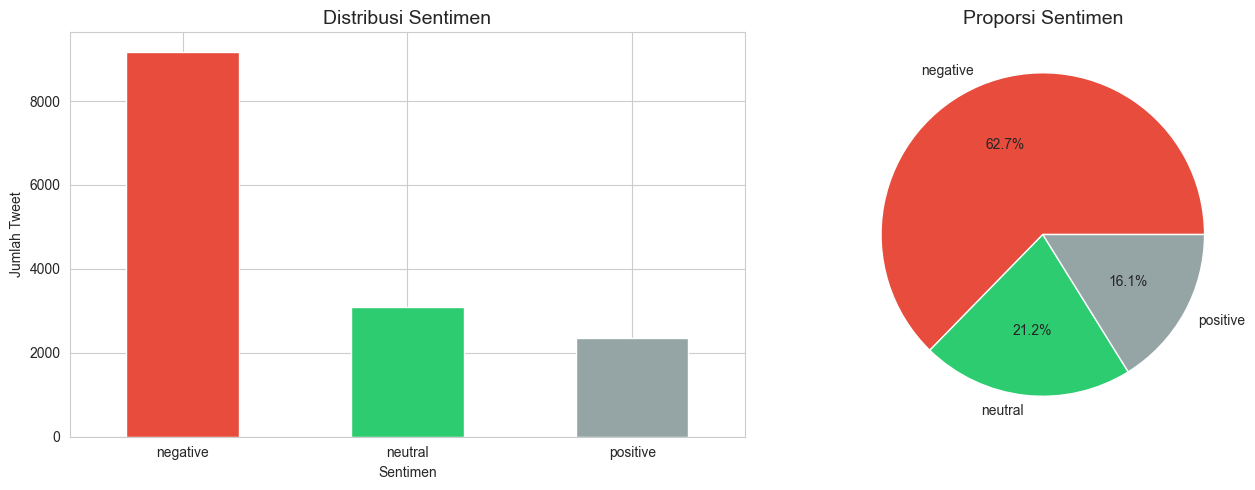

In [16]:
print('=== Distribusi Label (airline_sentiment) ===')
label_counts = df['airline_sentiment'].value_counts()
print(label_counts)
print(f'\nPersentase:')
print((label_counts / len(df) * 100).round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors = ['#e74c3c', '#2ecc71', '#95a5a6']
label_counts.plot(kind='bar', ax=axes[0], color=colors)
axes[0].set_title('Distribusi Sentimen', fontsize=14)
axes[0].set_xlabel('Sentimen')
axes[0].set_ylabel('Jumlah Tweet')
axes[0].tick_params(axis='x', rotation=0)

# Pie chart
label_counts.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', colors=colors)
axes[1].set_title('Proporsi Sentimen', fontsize=14)
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('../images/sentiment_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

**Hasil:**

| Sentimen | Jumlah | Persentase |
|----------|--------|------------|
| Negative | 9.178 | 62.69% |
| Neutral | 3.099 | 21.17% |
| Positive | 2.363 | 16.14% |

**Temuan penting:**
- Dataset **imbalanced** — kelas negative mendominasi (62.69%)
- Kelas positive paling sedikit (16.14%)
- **Dampak:** Model bisa bias ke kelas negative. Perlu perhatikan saat evaluasi (pakai f1-score, bukan hanya accuracy). Bisa pakai teknik seperti class_weight atau oversampling.

## 4. Distribusi Sentimen per Airline

=== Distribusi Sentimen per Airline ===
airline_sentiment  negative  neutral  positive
airline                                       
American               1960      463       336
Delta                   955      723       544
Southwest              1186      664       570
US Airways             2263      381       269
United                 2633      697       492
Virgin America          181      171       152


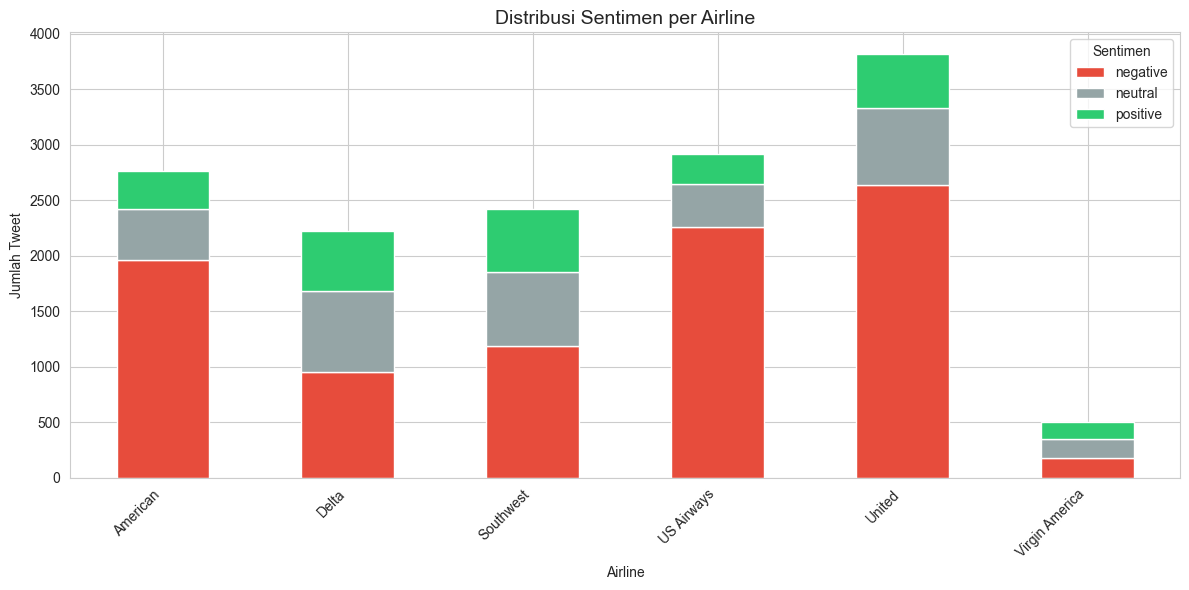

In [17]:
print('=== Distribusi Sentimen per Airline ===')
airline_sentiment = pd.crosstab(df['airline'], df['airline_sentiment'])
print(airline_sentiment)

airline_sentiment.plot(kind='bar', stacked=True, figsize=(12, 6),
                       color=['#e74c3c', '#95a5a6', '#2ecc71'])
plt.title('Distribusi Sentimen per Airline', fontsize=14)
plt.xlabel('Airline')
plt.ylabel('Jumlah Tweet')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Sentimen')
plt.tight_layout()
plt.savefig('../images/sentiment_per_airline.png', dpi=150, bbox_inches='tight')
plt.show()

**Hasil:**

| Airline | Negative | Neutral | Positive |
|---------|----------|---------|----------|
| United | 2.633 | 697 | 492 |
| US Airways | 2.263 | 381 | 269 |
| American | 1.960 | 463 | 336 |
| Southwest | 1.186 | 664 | 570 |
| Delta | 955 | 723 | 544 |
| Virgin America | 181 | 171 | 152 |

**Temuan penting:**
- **United** dan **US Airways** memiliki jumlah tweet negative paling banyak
- **Virgin America** paling seimbang antara ketiga sentimen
- **Delta** dan **Southwest** memiliki proporsi positive relatif lebih baik
- Secara keseluruhan, semua airline didominasi sentimen negative

## 5. Analisis Teks

In [18]:
# Hitung panjang teks
df['text_length'] = df['text'].apply(len)
df['word_count'] = df['text'].apply(lambda x: len(x.split()))

print('=== Statistik Panjang Teks ===')
print(f'\nBerdasarkan karakter:')
print(df.groupby('airline_sentiment')['text_length'].describe().round(2))
print(f'\nBerdasarkan kata:')
print(df.groupby('airline_sentiment')['word_count'].describe().round(2))

=== Statistik Panjang Teks ===

Berdasarkan karakter:
                    count    mean    std   min   25%    50%    75%    max
airline_sentiment                                                        
negative           9178.0  113.95  30.72  12.0  96.0  126.0  138.0  176.0
neutral            3099.0   87.36  37.68  12.0  57.0   87.0  123.0  167.0
positive           2363.0   86.08  39.48  12.0  52.0   86.0  124.0  186.0

Berdasarkan kata:
                    count   mean   std  min   25%   50%   75%   max
airline_sentiment                                                  
negative           9178.0  19.69  5.94  2.0  16.0  21.0  24.0  36.0
neutral            3099.0  14.41  6.96  2.0   9.0  14.0  20.0  31.0
positive           2363.0  14.01  7.04  2.0   8.0  14.0  20.0  31.0


**Hasil:**

| Sentimen | Rata-rata Karakter | Rata-rata Kata | Max Karakter |
|----------|-------------------|----------------|--------------|
| Negative | 113.95 | 19.69 | 176 |
| Neutral | 87.36 | 14.41 | 167 |
| Positive | 86.08 | 14.01 | 186 |

**Temuan penting:**
- Tweet **negative** cenderung **lebih panjang** (rata-rata 113.95 karakter / 19.69 kata)
- Tweet **neutral** dan **positive** panjangnya mirip (sekitar 86-87 karakter / 14 kata)
- Ini masuk akal — orang cenderung lebih banyak menulis saat mengeluh

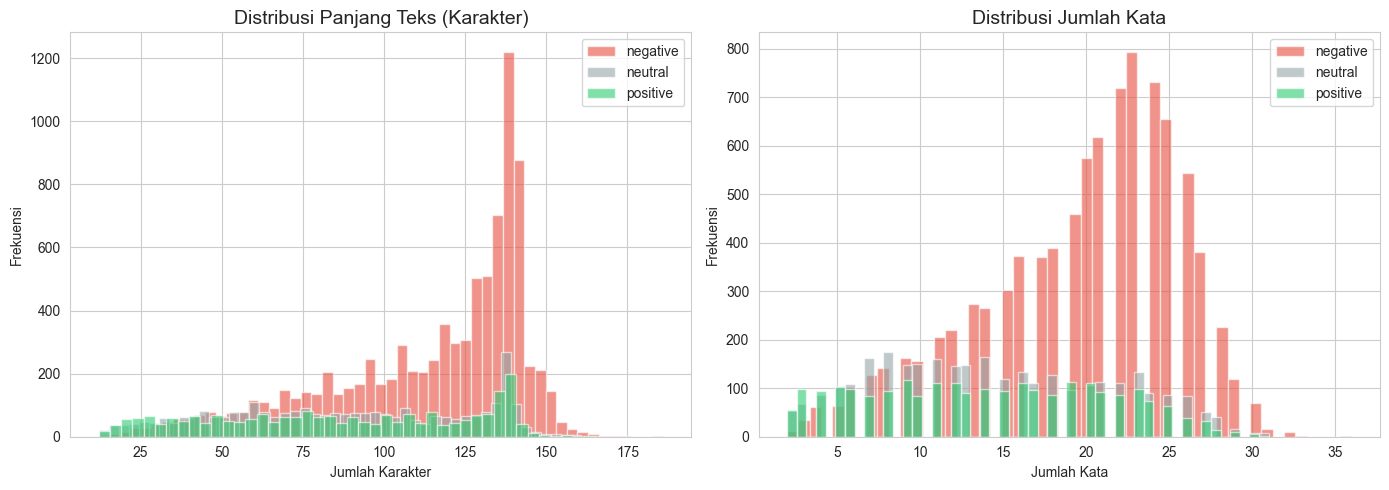

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribusi panjang teks per sentimen
for sent, color in zip(['negative', 'neutral', 'positive'], ['#e74c3c', '#95a5a6', '#2ecc71']):
    subset = df[df['airline_sentiment'] == sent]
    axes[0].hist(subset['text_length'], bins=50, alpha=0.6, label=sent, color=color)
axes[0].set_title('Distribusi Panjang Teks (Karakter)', fontsize=14)
axes[0].set_xlabel('Jumlah Karakter')
axes[0].set_ylabel('Frekuensi')
axes[0].legend()

# Distribusi jumlah kata per sentimen
for sent, color in zip(['negative', 'neutral', 'positive'], ['#e74c3c', '#95a5a6', '#2ecc71']):
    subset = df[df['airline_sentiment'] == sent]
    axes[1].hist(subset['word_count'], bins=50, alpha=0.6, label=sent, color=color)
axes[1].set_title('Distribusi Jumlah Kata', fontsize=14)
axes[1].set_xlabel('Jumlah Kata')
axes[1].set_ylabel('Frekuensi')
axes[1].legend()

plt.tight_layout()
plt.savefig('../images/text_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

**Hasil:**

Histogram menunjukkan:
- Distribusi panjang teks untuk **negative** (merah) bergeser ke kanan — lebih panjang
- Distribusi **neutral** (abu-abu) dan **positive** (hijau) lebih mirip, berpusat di sekitar 80-90 karakter
- Mayoritas tweet memiliki panjang 50-150 karakter (batas Twitter saat itu)



## 6. Sample Data per Label

In [20]:
print('=== Sample Tweet POSITIVE ===')
print(df[df['airline_sentiment'] == 'positive']['text'].head(3).values)
print()
print('=== Sample Tweet NEUTRAL ===')
print(df[df['airline_sentiment'] == 'neutral']['text'].head(3).values)
print()
print('=== Sample Tweet NEGATIVE ===')
print(df[df['airline_sentiment'] == 'negative']['text'].head(3).values)

=== Sample Tweet POSITIVE ===
["@VirginAmerica plus you've added commercials to the experience... tacky."
 '@VirginAmerica yes, nearly every time I fly VX this “ear worm” won’t go away :)'
 "@virginamerica Well, I didn't…but NOW I DO! :-D"]

=== Sample Tweet NEUTRAL ===
['@VirginAmerica What @dhepburn said.'
 "@VirginAmerica I didn't today... Must mean I need to take another trip!"
 '@VirginAmerica Really missed a prime opportunity for Men Without Hats parody, there. https://t.co/mWpG7grEZP']

=== Sample Tweet NEGATIVE ===
['@VirginAmerica it\'s really aggressive to blast obnoxious "entertainment" in your guests\' faces &amp; they have little recourse'
 "@VirginAmerica and it's a really big bad thing about it"
 "@VirginAmerica seriously would pay $30 a flight for seats that didn't have this playing.\nit's really the only bad thing about flying VA"]


**Hasil:**

**Positive:** Tweet berisi pujian atau pengalaman positif, contoh:
- "@VirginAmerica plus you've added commercials to the experience... tacky."
- "@VirginAmerica yes, nearly every time I fly VX this 'ear worm' won't go away :)"

**Neutral:** Tweet informatif atau pertanyaan, contoh:
- "@VirginAmerica What @dhepburn said."
- "@VirginAmerica I didn't today... Must mean I need to take another trip!"

**Negative:** Tweet keluhan, contoh:
- "@VirginAmerica it's really aggressive to blast obnoxious 'entertainment' in your guests' faces"
- "@VirginAmerica seriously would pay $30 a flight for seats that didn't have this playing."

**Temuan:**
- Semua tweet diawali dengan **mention (@)** — perlu dihapus saat preprocessing
- Terdapat **links** (https://...) — perlu dihapus
- Terdapat **tanda baca** dan **karakter khusus** (&amp;, "", dll) — perlu dibersihkan

## 7. Analisis Negative Reason (Opsional)

=== Top Negative Reasons ===
negativereason
Customer Service Issue         2910
Late Flight                    1665
Can't Tell                     1190
Cancelled Flight                847
Lost Luggage                    724
Bad Flight                      580
Flight Booking Problems         529
Flight Attendant Complaints     481
longlines                       178
Damaged Luggage                  74
Name: count, dtype: int64


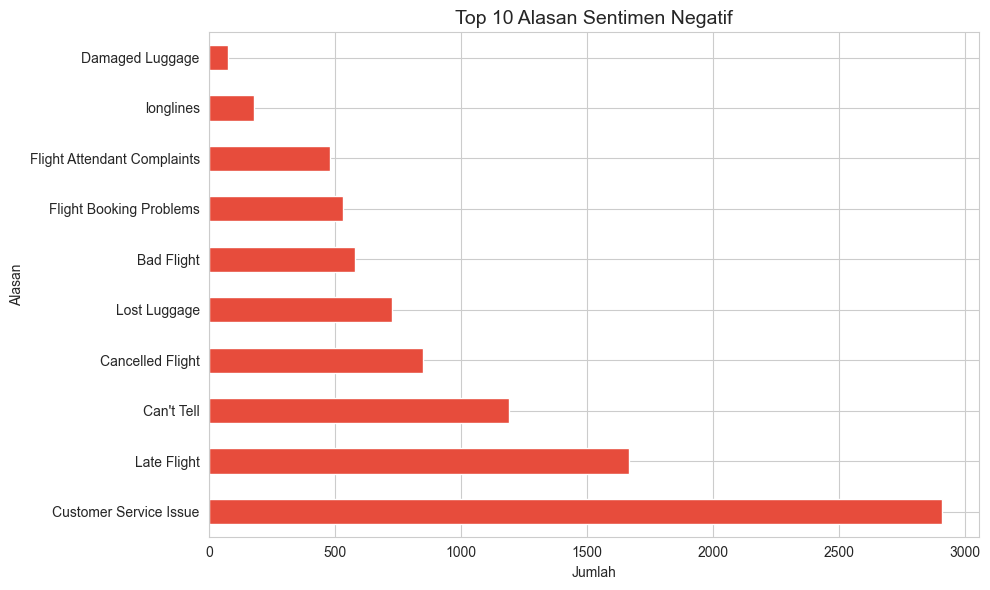

In [21]:
if 'negativereason' in df.columns:
    print('=== Top Negative Reasons ===')
    neg_reasons = df[df['airline_sentiment'] == 'negative']['negativereason'].value_counts().head(10)
    print(neg_reasons)
    
    neg_reasons.plot(kind='barh', figsize=(10, 6), color='#e74c3c')
    plt.title('Top 10 Alasan Sentimen Negatif', fontsize=14)
    plt.xlabel('Jumlah')
    plt.ylabel('Alasan')
    plt.tight_layout()
    plt.savefig('../images/negative_reasons.png', dpi=150, bbox_inches='tight')
    plt.show()

**Hasil:**

| Alasan | Jumlah |
|--------|--------|
| Customer Service Issue | 2.910 |
| Late Flight | 1.665 |
| Can't Tell | 1.190 |
| Cancelled Flight | 847 |
| Lost Luggage | 724 |
| Bad Flight | 580 |
| Flight Booking Problems | 529 |
| Flight Attendant Complaints | 481 |
| Long Lines | 178 |
| Damaged Luggage | 74 |

**Temuan:**
- **Customer Service Issue** adalah alasan terbesar (2.910 tweet) — hampir 1/3 dari semua tweet negative
- **Late Flight** di urutan kedua (1.665)
- Alasan ini bisa digunakan sebagai fitur tambahan atau untuk analisis lebih lanjut

## 8. Frekuensi Kata (Word Frequency)

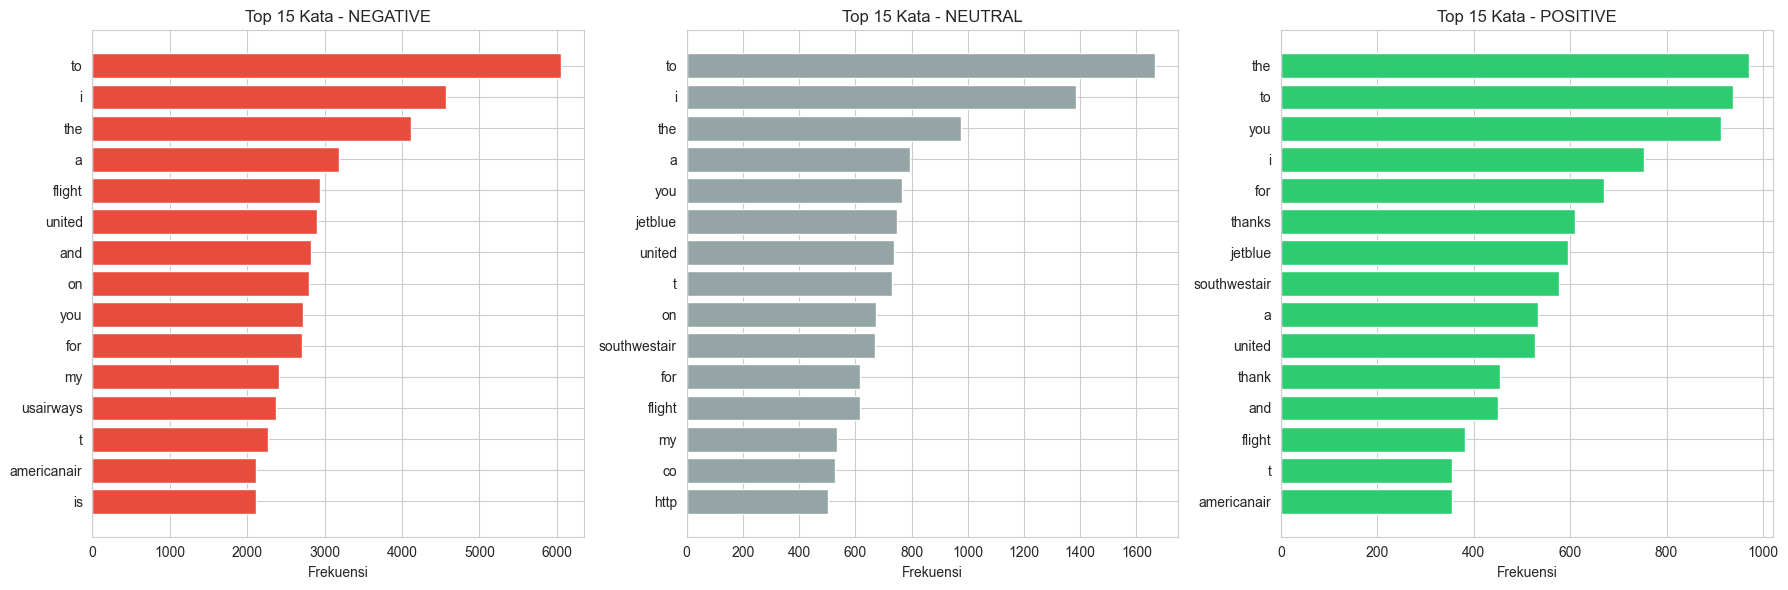

In [22]:
from collections import Counter
import re

def get_top_words(texts, n=20):
    words = []
    for text in texts:
        words.extend(re.findall(r'\b\w+\b', text.lower()))
    return Counter(words).most_common(n)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, sent in enumerate(['negative', 'neutral', 'positive']):
    texts = df[df['airline_sentiment'] == sent]['text']
    top_words = get_top_words(texts, 15)
    words, counts = zip(*top_words)
    
    axes[idx].barh(words[::-1], counts[::-1],
                   color=['#e74c3c', '#95a5a6', '#2ecc71'][idx])
    axes[idx].set_title(f'Top 15 Kata - {sent.upper()}', fontsize=12)
    axes[idx].set_xlabel('Frekuensi')

plt.tight_layout()
plt.savefig('../images/word_frequency.png', dpi=150, bbox_inches='tight')
plt.show()

**Hasil:**

Kata yang paling sering muncul di semua kelas adalah kata-kata umum seperti:
- **@mention** (nama airline seperti @united, @usairways, @americanair)
- **Kata kerja umum** (to, I, the, get, flight)
- **Kata terkait airline** (flight, plane, bag)

**Temuan penting:**
- Kata-kata **@mention** dan **kata umum** (stop words) mendominasi — tidak informatif untuk klasifikasi
- Perlu **stop words removal** dan **penghapusan @mention** saat preprocessing
- Kata-kata seperti "delayed", "cancelled", "lost" muncul di kelas negative — ini fitur yang berguna

## Ringkasan EDA

### Temuan Utama:

1. **Dataset:** 14.640 tweet tentang 6 airline di AS
2. **Label:** 3 kelas — negative (62.69%), neutral (21.17%), positive (16.14%)
3. **Imbalanced:** Kelas negative mendominasi — perlu perhatikan saat evaluasi
4. **Kolom yang dipakai:** Hanya `text` (fitur) dan `airline_sentiment` (label)
5. **Karakteristik teks:**
   - Tweet negative cenderung lebih panjang (rata-rata 113.95 karakter)
   - Mengandung @mention, links, tanda baca — perlu dibersihkan
   - Kata-kata umum (stop words) mendominasi — perlu stop words removal

### Langkah Selanjutnya (Preprocessing):
- Hapus @mention, links, hashtag
- Hapus tanda baca dan angka
- Pertimbangkan stop words removal (kecuali untuk sentiment analysis)
- Lowercase semua teks

**Lanjut ke notebook berikutnya: `02_preprocessing.ipynb`**